In [1]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt
import os
from scipy.spatial import cKDTree
from typing import Literal
import pandas as pd

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

filename = os.path.join("..", "datasets", "GSM6592049_M2.h5ad")

adata = sc.read_h5ad(filename)
adata = adata[adata.obs["in_tissue"] == True, :]
adata.var_names_make_unique()

13 mitochondrial genes


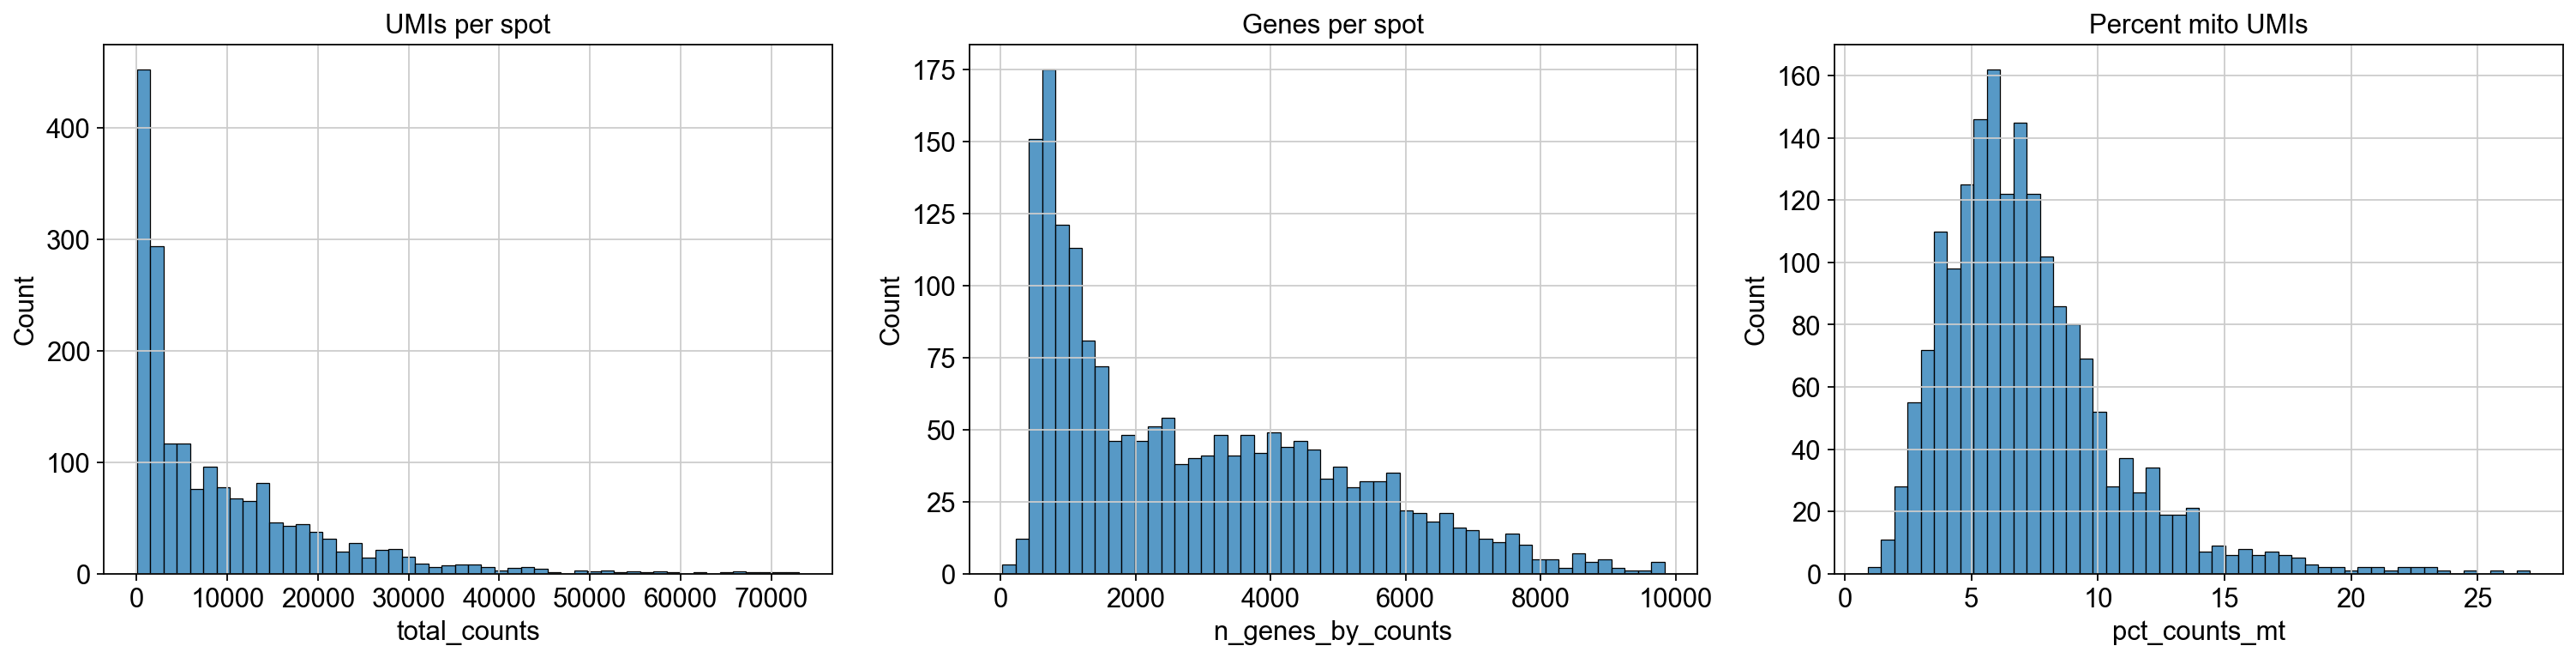

In [2]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print(adata.var["mt"].sum(), "mitochondrial genes")

# calculate per-spot QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)


#  plot QC metrics
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(adata.obs["total_counts"], bins=50, kde=False, ax=axes[0])
axes[0].set_title("UMIs per spot")

sns.histplot(adata.obs["n_genes_by_counts"], bins=50, kde=False, ax=axes[1])
axes[1].set_title("Genes per spot")

sns.histplot(adata.obs["pct_counts_mt"], bins=50, kde=False, ax=axes[2])
axes[2].set_title("Percent mito UMIs")

plt.tight_layout()
plt.show()

In [3]:
def modified_z_score(values, s=1.4826):
    """
    Compute modified z-scores as in the R `spatialEco::outliers` function.
    Median Absolute Deviation (MAD) based robust z-score.
    """
    values = np.array(values, dtype=float)

    median_val = np.median(values)
    mad_val = np.median(np.abs(values - median_val))
    if mad_val == 0:
        return np.zeros_like(values)
    return 0.6745 * (values - median_val) / mad_val


def local_outliers(
    adata,
    metric: str = "n_genes_by_counts",
    direction: Literal["lower", "higher"] = "lower",
    n_neighbors: int = 36,
    samples: str = "Sample_ID",
    cutoff: float = 3
):
    """
    Detect local outliers in spatial transcriptomics data.

    Parameters
    ----------
    adata : AnnData
        AnnData object with `obsm['spatial']` and QC metric in `obs`.
    metric : str
        Column in adata.obs to use for outlier detection.
    direction : {"lower", "higher"}
        Whether to detect low or high outliers.
    n_neighbors : int
        Number of nearest neighbors to consider.
    samples : str
        Column in adata.obs containing sample IDs (batch).
    cutoff : float
        Modified z-score threshold for calling outliers.

    Returns
    -------
    AnnData
        Updated AnnData with new columns:
        - `<metric>_z`: modified z-scores
        - `<metric>_outliers`: boolean array for detected outliers
    """
    # Loop through each unique sample IDs
    all_results = []
    for sample_id in adata.obs[samples].unique():
        # Subset the data for the current sample
        subset = adata.obs[samples] == sample_id
        adata_sub = adata[subset].copy()

        # Create a list of spatial coordinates and qc features
        coords = np.array(adata_sub.obsm["spatial"])
        values = adata_sub.obs[metric].values

         # Find nearest neighbors (excluding self)
        tree = cKDTree(coords)
        _, idx = tree.query(coords, k=n_neighbors + 1)
        idx = idx[:, 1:]  # remove self from neighbor list
        
        # idx[i, j] = index of the j-th nearest neighbor of spot i
        
        # get neighborhood metrics (including self) for each spot
        z_scores = []
        for i in range(idx.shape[0]):
            neighbor_vals = values[np.concatenate(([i], idx[i]))]
            z = modified_z_score(neighbor_vals)[0]  # score for the central spot
            z_scores.append(z)
        
        # find outliers based on cutoff, store in outlier_flags
        z_scores = np.array(z_scores)
        outlier_flags = np.zeros_like(z_scores, dtype=bool)

        if direction == "higher":
            outlier_flags = z_scores > cutoff
        elif direction == "lower":
            outlier_flags = z_scores < -cutoff

        # save z-scores and outliers
        result_df = pd.DataFrame({
            f"{metric}_z": z_scores,
            f"{metric}_outliers": outlier_flags
        }, index=adata_sub.obs.index)

        all_results.append(result_df)
        
    # Merge results into main AnnData.obs
    results_df = pd.concat(all_results)
    adata.obs = adata.obs.join(results_df)

    return adata

C:\Users\rebec\AppData\Local\Temp\ipykernel_13676\4274316504.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_13676\4274316504.py:27: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


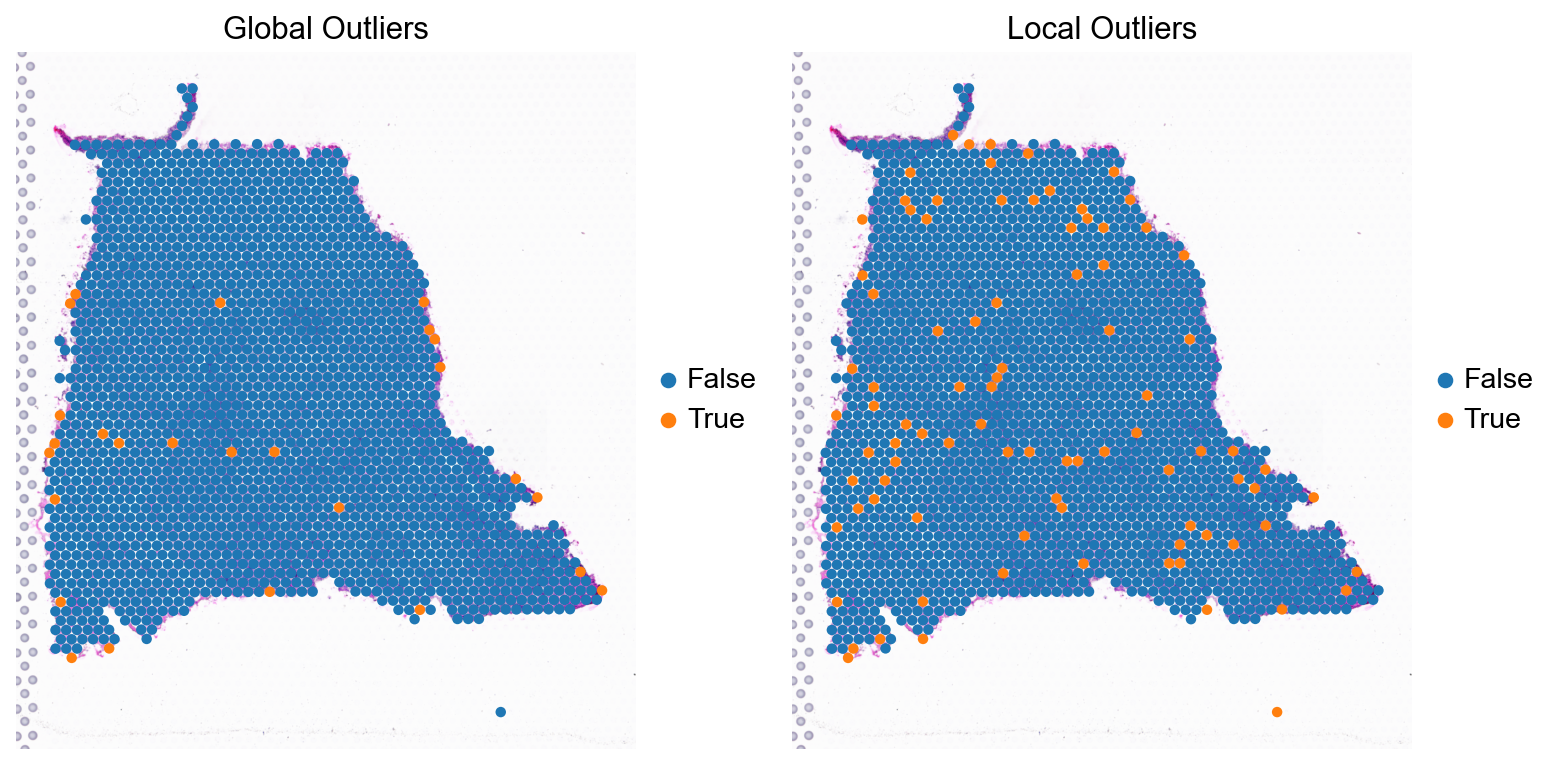

In [4]:
# global outlier detection
adata.obs["qc_lib_size"] = adata.obs["total_counts"] < 500
adata.obs["qc_detected"] = adata.obs["n_genes_by_counts"] < 400
adata.obs["qc_mito_prop"] = adata.obs["pct_counts_mt"] > 20

adata.obs["global_outliers"] = (adata.obs["qc_lib_size"].values) | (adata.obs["qc_detected"].values) | (adata.obs["qc_mito_prop"].values)

# local outlier detection
local_outliers(adata, "log1p_total_counts", "lower", 3)
local_outliers(adata, "log1p_n_genes_by_counts", "lower", 3)
local_outliers(adata, "pct_counts_mt", "higher", 3)

adata.obs["local_outliers"] = (adata.obs["log1p_total_counts_outliers"].values) | (adata.obs["log1p_n_genes_by_counts_outliers"].values) | (adata.obs["pct_counts_mt_outliers"].values)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

sc.pl.spatial(
    adata,
    color="global_outliers",
    library_id="GSM6592049_M2",
    size=1.5,
    title="Global Outliers",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="local_outliers",
    library_id="GSM6592049_M2",
    size=1.5,
    title="Local Outliers",
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

C:\Users\rebec\AppData\Local\Temp\ipykernel_13676\1900768520.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_13676\1900768520.py:16: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


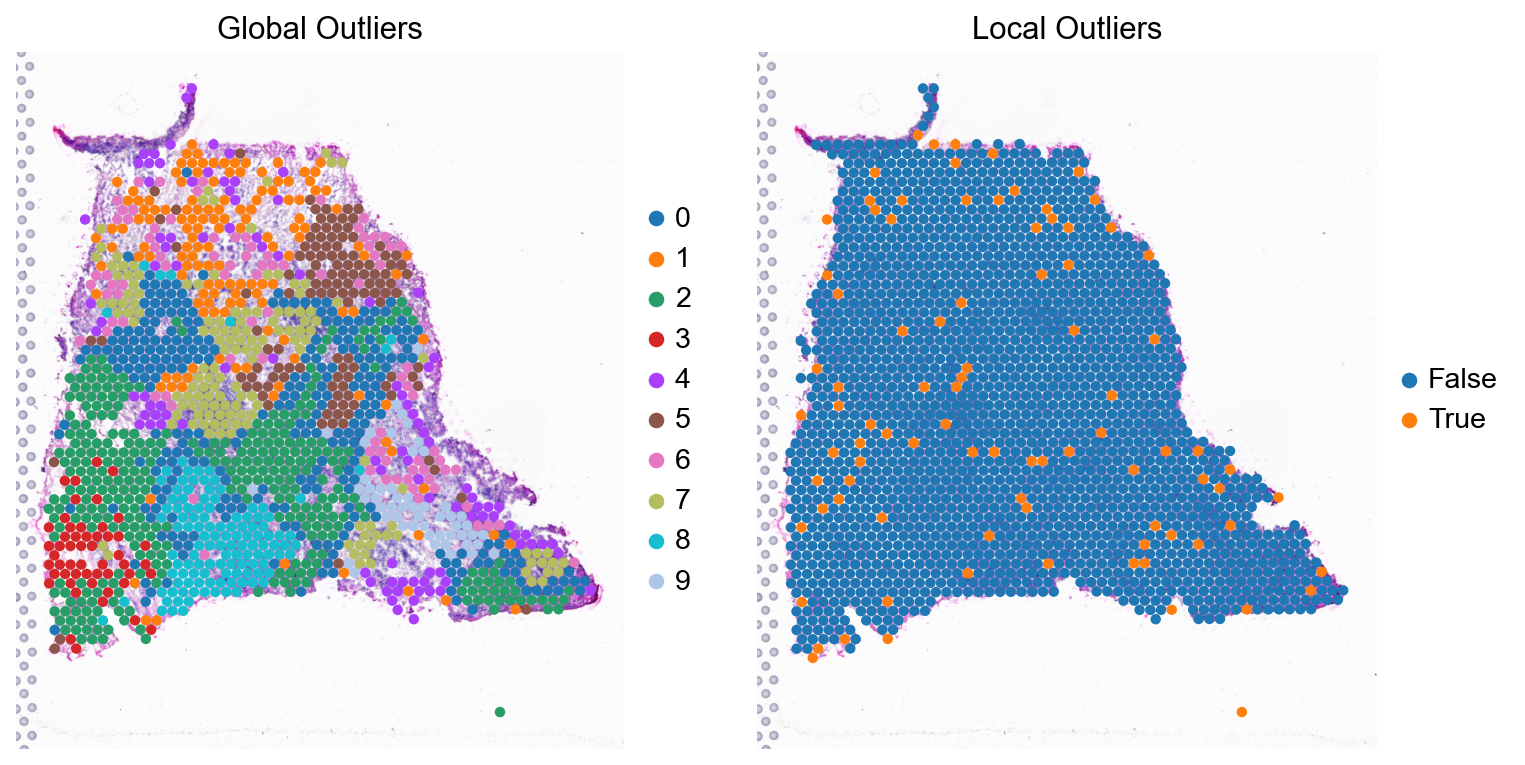

In [5]:
output_path_file = os.path.join(f"{os.path.dirname(filename)}_prepro", f"{os.path.basename(filename).split('.h5')[0]}_prepro.h5ad")
adata_prepro = sc.read_h5ad(output_path_file)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

sc.pl.spatial(
    adata_prepro,
    color="leiden",
    library_id="GSM6592049_M2",
    size=1.5,
    title="Global Outliers",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="local_outliers",
    library_id="GSM6592049_M2",
    size=1.5,
    title="Local Outliers",
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.global_outliers) & (~adata.obs.local_outliers)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

TODO: 
- save plots
- clean andata (e.g. remove added columns and maybe other columns ('B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells') to save space)